In [ ]:
#2541 Samuel D'Souza
#2543 Sanjeet Velip

#AI ML Mini Project

import pandas

dataframe = pandas.read_csv("classification_road_accidents_100k.csv")
dataframe.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,time_of_day,accident
0,rural,2,0.29,70,night,rainy,evening,1
1,highway,1,0.34,25,dim,clear,morning,0
2,rural,2,0.76,70,night,foggy,evening,1
3,rural,3,0.37,70,night,foggy,morning,1
4,highway,3,0.39,45,dim,rainy,morning,0


In [3]:
dataframe.shape

(100000, 8)

In [4]:
dataframe.isnull().any()

,0
road_type,False
num_lanes,False
curvature,False
speed_limit,False
lighting,False
weather,False
time_of_day,False
accident,False


In [5]:
categorical_columns = ['road_type', 'lighting', 'weather', 'time_of_day']
numerical_columns = ['num_lanes', 'curvature', 'speed_limit']

for column in categorical_columns:
    print(dataframe[column].name, dataframe[column].unique())

road_type ['rural' 'highway' 'urban']
lighting ['night' 'dim' 'daylight']
weather ['rainy' 'clear' 'foggy']
time_of_day ['evening' 'morning' 'afternoon']


skipped principal component analysis because: PCA requires numerical data, performing one hot encoding on the above categorical columns would create a sprase matrix, therefore undermining the actual numerical columns.

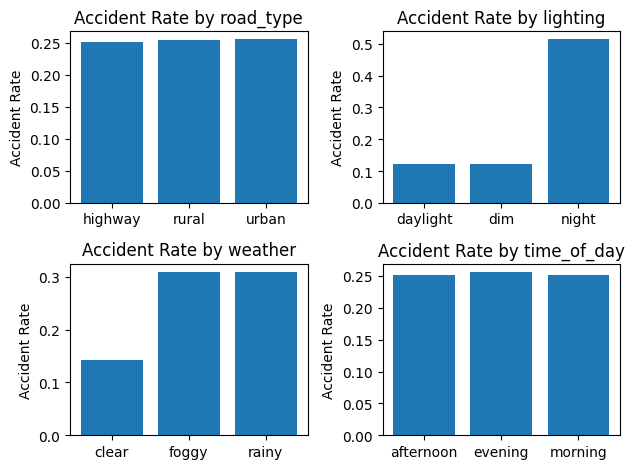

In [6]:
from matplotlib import pyplot

fig = pyplot.figure()
axes = fig.subplots(2, 2)
axes = axes.flatten()

for index, value in enumerate(categorical_columns):
    accident_rate = (dataframe.groupby(value)['accident'].mean())
    axes[index].bar(accident_rate.index, accident_rate.values)
    axes[index].set_title(f'Accident Rate by {value}')
    axes[index].set_ylabel('Accident Rate')

pyplot.tight_layout()
pyplot.show()

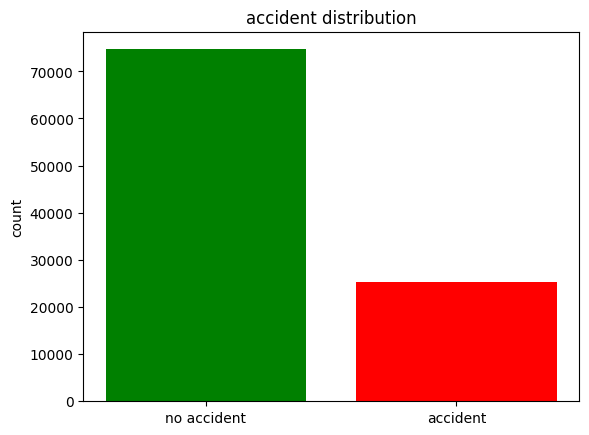

In [7]:
counts = dataframe['accident'].value_counts()

pyplot.bar(['no accident', 'accident'], counts, color=['green', 'red'])
pyplot.title('accident distribution')
pyplot.ylabel('count')
pyplot.show()

the above graph shows that the dataset is not balanced, this will cause models to guess the majority class every time to achieve high accuracy, failing to actually predict accidents. SMOTENC will balence it, but the dataset needs to be converted to numerical data.

In [8]:
independent = dataframe.drop('accident', axis=1)
independent.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,time_of_day
0,rural,2,0.29,70,night,rainy,evening
1,highway,1,0.34,25,dim,clear,morning
2,rural,2,0.76,70,night,foggy,evening
3,rural,3,0.37,70,night,foggy,morning
4,highway,3,0.39,45,dim,rainy,morning


In [9]:
dependent = dataframe['accident']
dependent.unique()

array([1, 0])

In [10]:
from sklearn.model_selection import train_test_split

independent_train, independent_test, dependent_train, dependent_test = train_test_split(independent, dependent, test_size=0.3, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
independent_train[numerical_columns] = scaler.fit_transform(independent_train[numerical_columns])
independent_test[numerical_columns] = scaler.transform(independent_test[numerical_columns])

from imblearn.over_sampling import SMOTENC

smotenc = SMOTENC(categorical_features=categorical_columns, random_state=42)
independent_train, dependent_train = smotenc.fit_resample(independent_train, dependent_train)

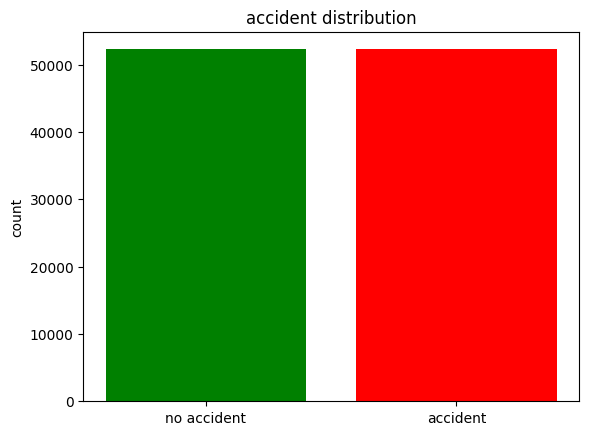

In [11]:
counts = dependent_train.value_counts()

pyplot.bar(['no accident', 'accident'], counts, color=['green', 'red'])
pyplot.title('accident distribution')
pyplot.ylabel('count')
pyplot.show()

In [12]:
#converting categorical data to numerical
independent_train = pandas.get_dummies(independent_train, drop_first=True)
independent_test = pandas.get_dummies(independent_test, drop_first=True)

independent_train.shape

(104526, 11)

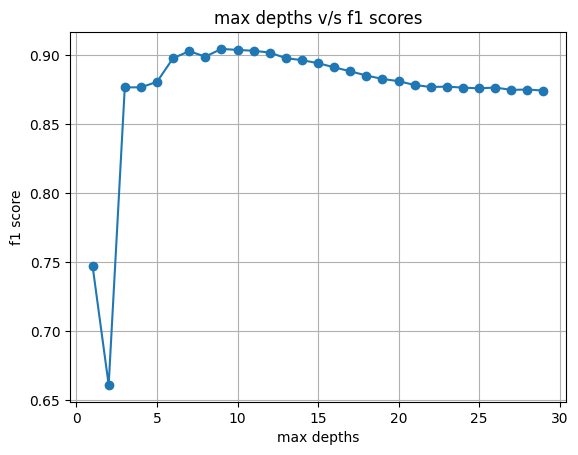

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

f1_scores = []

for i in range(1, 30):
    decision_tree_classifier = DecisionTreeClassifier(max_depth=i, random_state=42)
    decision_tree_classifier.fit(independent_train, dependent_train)

    dependent_prediction = decision_tree_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(1,30), f1_scores, marker='o')
pyplot.title('max depths v/s f1 scores')
pyplot.xlabel('max depths')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 7 is a good depth for this decision tree.

In [14]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=7, random_state=42)
decision_tree_classifier.fit(independent_train, dependent_train)

dependent_prediction = decision_tree_classifier.predict(independent_test)

from sklearn.metrics import recall_score, precision_score

decision_tree_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
decision_tree_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
decision_tree_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

from sklearn.metrics import classification_report

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.97      0.90      0.93     22421
    accident       0.75      0.90      0.82      7579

    accuracy                           0.90     30000
   macro avg       0.86      0.90      0.88     30000
weighted avg       0.91      0.90      0.90     30000



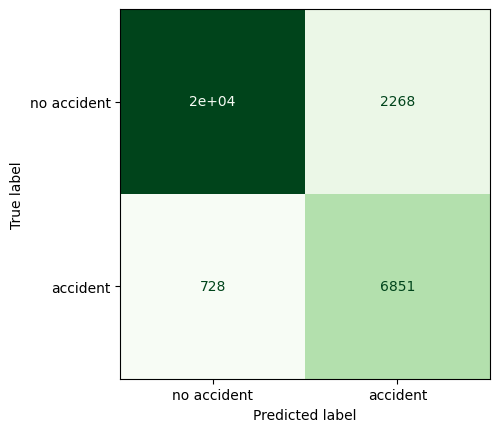

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

visualizing a tree of 7 levels is difficult, therefore to demonstrate, a tree of 3 levels is visualised

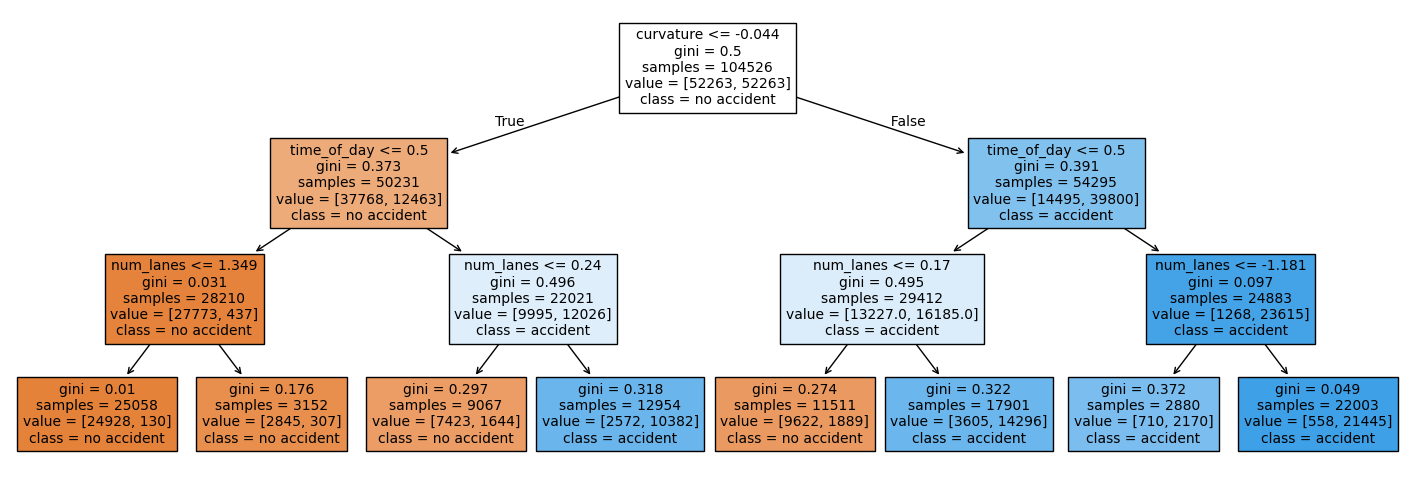

In [30]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree_classifier.fit(independent_train, dependent_train)

from matplotlib import pyplot
from sklearn.tree import plot_tree

pyplot.figure(figsize = [18, 6])
plot_tree(decision_tree_classifier, feature_names = independent.columns, class_names = ["no accident", "accident"], filled = True, fontsize = 10)
pyplot.show()

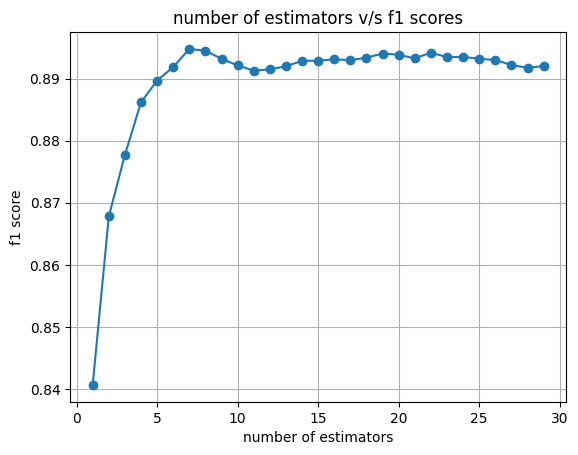

In [17]:
from sklearn.ensemble import RandomForestClassifier

f1_scores = []

for i in range(1, 30):
    random_forest_classifier = RandomForestClassifier(n_estimators=i, max_depth=7, random_state=42, n_jobs=-1)
    random_forest_classifier.fit(independent_train, dependent_train)

    dependent_prediction = random_forest_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(1,30), f1_scores, marker='o')
pyplot.title('number of estimators v/s f1 scores')
pyplot.xlabel('number of estimators')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 7 is a good number of estimators for this random forest

In [31]:
random_forest_classifier = RandomForestClassifier(n_estimators=7, max_depth=7, random_state=42, n_jobs=-1)
random_forest_classifier.fit(independent_train, dependent_train)

dependent_prediction = random_forest_classifier.predict(independent_test)

random_forest_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
random_forest_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
random_forest_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.97      0.89      0.92     22421
    accident       0.73      0.91      0.81      7579

    accuracy                           0.89     30000
   macro avg       0.85      0.90      0.87     30000
weighted avg       0.91      0.89      0.89     30000



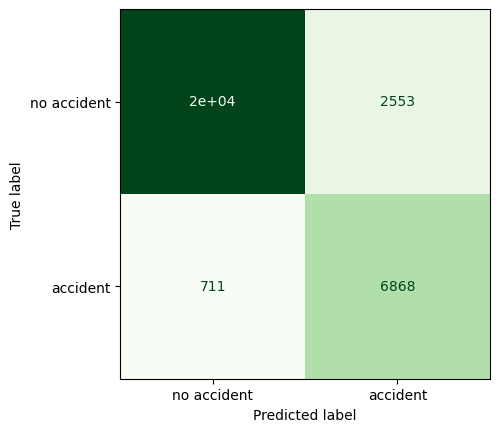

In [32]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

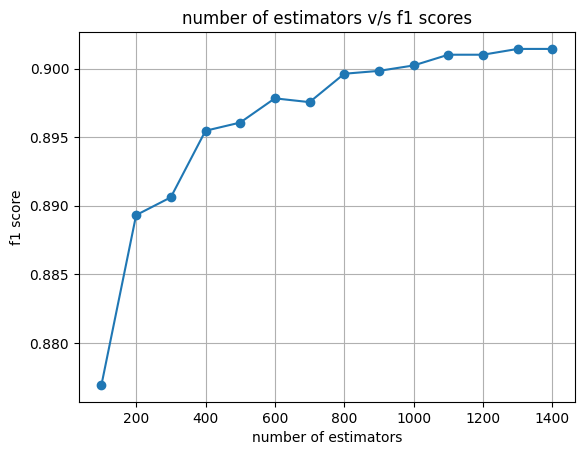

In [20]:
from sklearn.ensemble import AdaBoostClassifier

f1_scores = []

for i in range(100, 1500, 100):
    ada_boost_classifier = AdaBoostClassifier(n_estimators=i, learning_rate=0.1, random_state=42)
    #not specifying the max_depth as ada boost uses trees of 1 level
    ada_boost_classifier.fit(independent_train, dependent_train)

    dependent_prediction = ada_boost_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(100, 1500, 100), f1_scores, marker='o')
pyplot.title('number of estimators v/s f1 scores')
pyplot.xlabel('number of estimators')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 400 is a good number of estimators for this ada boost

In [33]:
ada_boost_classifier = AdaBoostClassifier(n_estimators=400, learning_rate=0.1, random_state=42)
ada_boost_classifier.fit(independent_train, dependent_train)

dependent_prediction = ada_boost_classifier.predict(independent_test)

ada_boost_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
ada_boost_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
ada_boost_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.97      0.89      0.92     22421
    accident       0.73      0.91      0.81      7579

    accuracy                           0.89     30000
   macro avg       0.85      0.90      0.87     30000
weighted avg       0.91      0.89      0.90     30000



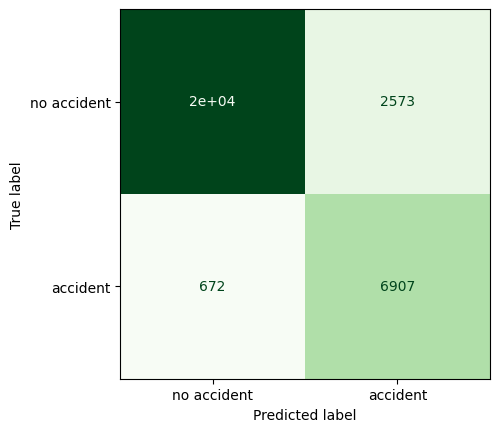

In [34]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

In [23]:
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

set_random_seed(42)

model = Sequential([
    #input shape
    Input((11,)),

    #hidden layers: 16 and 8 neurons
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),

    #prevents overfitting by randomly turning off neurons
    Dropout(0.2),

    #output layer: 1 neuron with sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(independent_train, dependent_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8640 - loss: 0.3717
Epoch 2/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8957 - loss: 0.2672
Epoch 3/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8961 - loss: 0.2564
Epoch 4/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8967 - loss: 0.2535
Epoch 5/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8954 - loss: 0.2533
Epoch 6/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8977 - loss: 0.2517
Epoch 7/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8954 - loss: 0.2528
Epoch 8/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8972 - loss: 0.2513
Epoch 9/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8972 - loss: 0.2512
Epoch 10/50
3267/3267 - 8s - 2ms/step - accuracy: 0.8972 - loss: 0.2520
Epoch 11/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8964 - loss: 0.2515
Epoch 12/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8963 - loss: 0.2510
Epoch 13/50
3267/3267 - 6s - 2ms/step - accuracy: 0.8971 - loss: 0.2507
Epoch 14/50
3267/3267 - 7s - 2ms/step - accuracy: 0.8969 - loss: 0.2506
E

In [24]:
probabilities = model.predict(independent_test, verbose=2)
dependent_prediction = (probabilities > 0.5).astype(int)

neural_network_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
neural_network_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
neural_network_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

938/938 - 1s - 1ms/step
              precision    recall  f1-score   support

 no accident       0.97      0.89      0.93     22421
    accident       0.74      0.91      0.82      7579

    accuracy                           0.90     30000
   macro avg       0.85      0.90      0.87     30000
weighted avg       0.91      0.90      0.90     30000



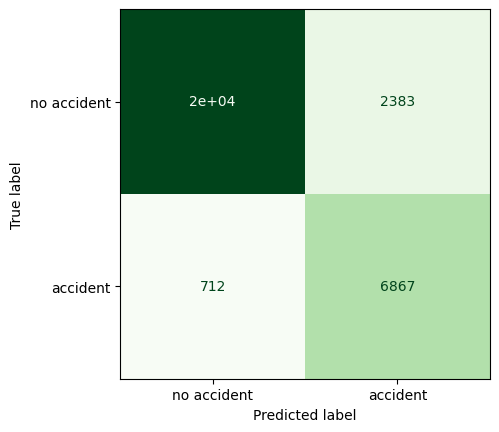

In [25]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

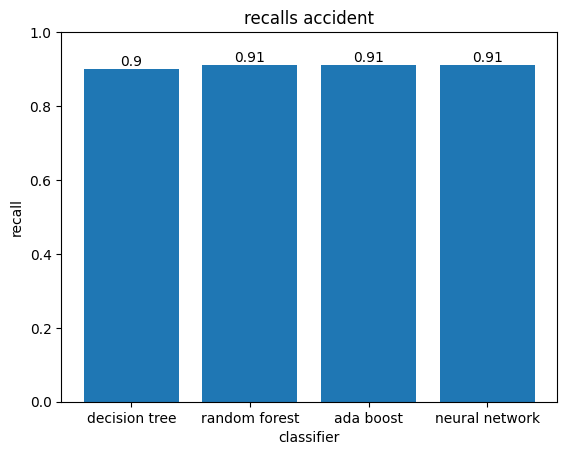

In [35]:
classifiers = ["decision tree", "random forest", "ada boost", "neural network"]
classifiers_recalls_accident = [decision_tree_recall_accident, random_forest_recall_accident, ada_boost_recall_accident, neural_network_recall_accident]

pyplot.bar(classifiers, classifiers_recalls_accident)

for i in range(len(classifiers_recalls_accident)):
    pyplot.text(i, classifiers_recalls_accident[i] + 0.01, classifiers_recalls_accident[i], ha='center')

pyplot.title('recalls accident')
pyplot.xlabel('classifier')
pyplot.ylabel('recall')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph for the positive class (accident):
*   random forest, ada boost and neural network have the highest recall
*   decision tree has the lowest recall

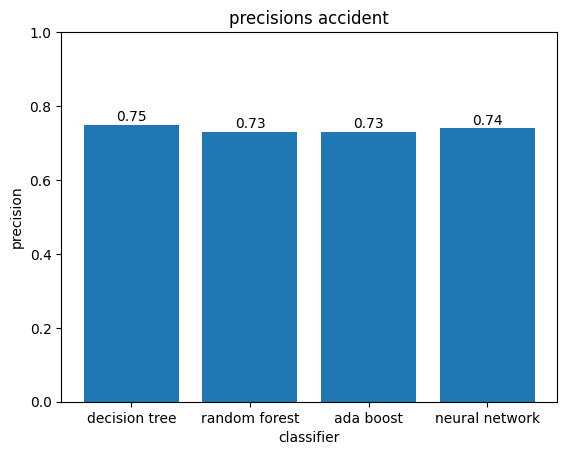

In [36]:
classifiers_precisions_accident = [decision_tree_precision_accident, random_forest_precision_accident, ada_boost_precision_accident, neural_network_precision_accident]

pyplot.bar(classifiers, classifiers_precisions_accident)

for i in range(len(classifiers_precisions_accident)):
    pyplot.text(i, classifiers_precisions_accident[i] + 0.01, classifiers_precisions_accident[i], ha='center')

pyplot.title('precisions accident')
pyplot.xlabel('classifier')
pyplot.ylabel('precision')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph for the positive class (accident):
*   decision tree has the highest precision
*   random forest and ada boost have the lowest precision

neural network has the highest recall among the three highest recall classifiers

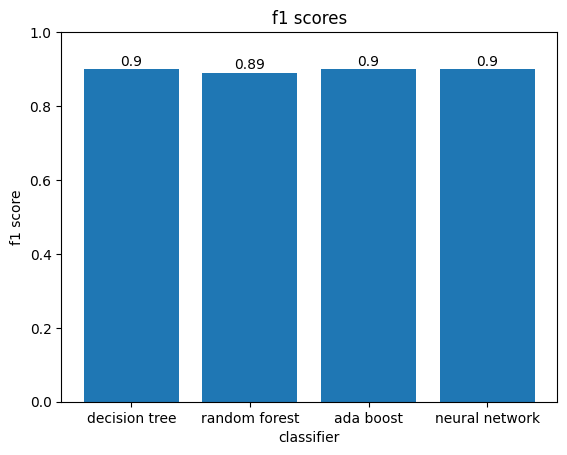

In [37]:
classifiers_f1_scores = [decision_tree_f1_score, random_forest_f1_score, ada_boost_f1_score, neural_network_f1_score]

pyplot.bar(classifiers, classifiers_f1_scores)

for i in range(len(classifiers_f1_scores)):
    pyplot.text(i, classifiers_f1_scores[i] + 0.01, classifiers_f1_scores[i], ha='center')

pyplot.title('f1 scores')
pyplot.xlabel('classifier')
pyplot.ylabel('f1 score')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph, neural network is among the three highest F1 score classifiers

therefore, choosing neural network in this case is proper because:
*   it has the highest overall score
*   slightly faster to train compared to ada boost on a CPU
*   quite faster to train compared to ada boost on a GPU